# Customer Churn — Exploratory Data Analysis

## Business context
Customer churn prediction helps companies identify customers who are likely to leave and understand the drivers of attrition.

## Objective of this notebook
This notebook explores the IBM Telco Customer Churn dataset in order to answer the following questions:

1. What is the overall churn rate?
2. Which variables seem associated with churn?
3. Are there missing or inconsistent values?
4. Is the target imbalanced?
5. Which customer segments appear most at risk?

## Notebook scope
This notebook focuses on:
- data overview and quality checks,
- churn distribution,
- categorical and numerical patterns,
- first business hypotheses for modeling.

It does **not** train predictive models yet.

In [43]:
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid")

DB_PATH = Path("../data/processed/churn.duckdb")
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EXPORT_FIGURES = False


def save_fig(filename: str) -> None:
    if EXPORT_FIGURES:
        plt.savefig(FIGURES_DIR / filename, bbox_inches="tight", dpi=300)

In [44]:
conn = duckdb.connect(str(DB_PATH))

df_raw = conn.execute("SELECT * FROM raw_customers").df()
df_feat = conn.execute("SELECT * FROM customer_features").df()

print("raw_customers shape:", df_raw.shape)
print("customer_features shape:", df_feat.shape)

df_raw.head()

raw_customers shape: (7043, 21)
customer_features shape: (7043, 26)


,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.850,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,"1,889.500",0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.150,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,"1,840.750",0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.650,1


## 1. Dataset overview

We first inspect the shape, data types, and a quick preview of the dataset before analyzing churn patterns.

In [45]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   gender             7043 non-null   object 
 2   senior_citizen     7043 non-null   int32  
 3   partner            7043 non-null   object 
 4   dependents         7043 non-null   object 
 5   tenure             7043 non-null   int32  
 6   phone_service      7043 non-null   object 
 7   multiple_lines     7043 non-null   object 
 8   internet_service   7043 non-null   object 
 9   online_security    7043 non-null   object 
 10  online_backup      7043 non-null   object 
 11  device_protection  7043 non-null   object 
 12  tech_support       7043 non-null   object 
 13  streaming_tv       7043 non-null   object 
 14  streaming_movies   7043 non-null   object 
 15  contract           7043 non-null   object 
 16  paperless_billing  7043 

In [46]:
overview = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "missing_count": df_raw.isna().sum().values,
    "missing_pct": (df_raw.isna().mean() * 100).round(2).values,
    "n_unique": df_raw.nunique(dropna=False).values
})

overview.sort_values(by=["missing_count", "n_unique"], ascending=[False, False]).reset_index(drop=True)

,column,dtype,missing_count,missing_pct,n_unique
0,total_charges,float64,11,0.160,6531
1,customer_id,object,0,0.000,7043
2,monthly_charges,float64,0,0.000,1585
3,tenure,int32,0,0.000,73
4,payment_method,object,0,0.000,4
5,multiple_lines,object,0,0.000,3
6,internet_service,object,0,0.000,3
7,online_security,object,0,0.000,3
8,online_backup,object,0,0.000,3
9,device_protection,object,0,0.000,3


In [47]:
print("Duplicate customer_id values:", df_raw["customer_id"].duplicated().sum())
print("Distinct churn values:", sorted(df_raw["churn"].dropna().unique().tolist()))
print("\nRows with missing total_charges:", df_raw["total_charges"].isna().sum())

df_raw[df_raw["total_charges"].isna()].head(11)

Duplicate customer_id values: 0
Distinct churn values: [0, 1]

Rows with missing total_charges: 11


,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.550,NaN,0
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.250,NaN,0
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.850,NaN,0
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.750,NaN,0
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.050,NaN,0
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.850,NaN,0
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.350,NaN,0
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.000,NaN,0
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.700,NaN,0
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.350,NaN,0


## 2. Data quality checks

A few checks are important before any modeling:
- duplicates on customer identifier,
- missing values,
- target consistency,
- potential anomalies in billing variables.

In this dataset, the main issue is the small number of missing values in `total_charges`.

In [48]:
missing_total_charges_summary = (
    df_raw[df_raw["total_charges"].isna()][["tenure", "monthly_charges", "churn"]]
    .describe(include="all")
)

missing_total_charges_summary

,tenure,monthly_charges,churn
count,11.000,11.000,11.000
mean,0.000,41.418,0.000
std,0.000,23.831,0.000
min,0.000,19.700,0.000
25%,0.000,20.125,0.000
50%,0.000,25.750,0.000
75%,0.000,58.975,0.000
max,0.000,80.850,0.000


All missing values in `total_charges` correspond to customers with `tenure = 0`, which is consistent with new customers who have not yet accumulated any total charges.

## 3. Target distribution

We now examine the global churn rate and verify whether the target is imbalanced.

In [49]:
churn_counts = df_raw["churn"].value_counts().sort_index()
churn_rate = df_raw["churn"].mean()

summary_target = pd.DataFrame({
    "churn_label": ["No churn (0)", "Churn (1)"],
    "count": [churn_counts.get(0, 0), churn_counts.get(1, 0)],
    "percentage": [
        churn_counts.get(0, 0) / len(df_raw) * 100,
        churn_counts.get(1, 0) / len(df_raw) * 100,
    ]
})

print(f"Global churn rate: {churn_rate:.2%}")
summary_target

Global churn rate: 26.54%


,churn_label,count,percentage
0,No churn (0),5174,73.463
1,Churn (1),1869,26.537


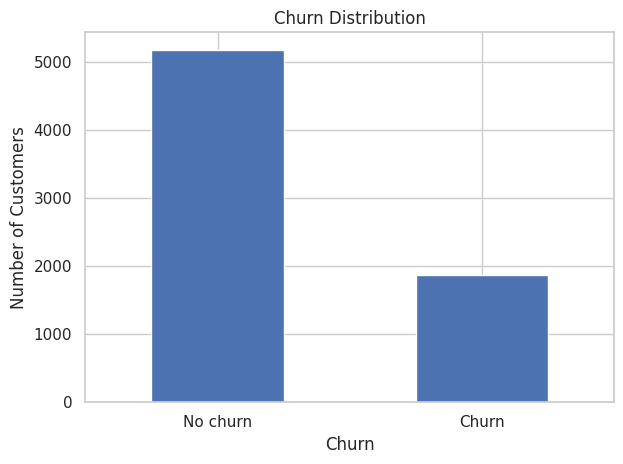

In [50]:
ax = df_raw["churn"].value_counts().sort_index().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["No churn", "Churn"], rotation=0)
plt.tight_layout()
save_fig("eda_01_churn_distribution.png")
plt.show()

## 4. Helper functions for EDA

To keep the notebook clean and reproducible, the following helper functions are used for repeated analyses.

In [51]:
def churn_rate_table(df: pd.DataFrame, column: str) -> pd.DataFrame:
    table = (
        df.groupby(column)
        .agg(
            customers=("churn", "size"),
            churn_rate=("churn", "mean")
        )
        .sort_values("churn_rate", ascending=False)
        .reset_index()
    )
    table["churn_rate_pct"] = (table["churn_rate"] * 100).round(2)
    return table


def plot_churn_rate_by_category(df: pd.DataFrame, column: str, title: str, filename: str | None = None):
    table = churn_rate_table(df, column)

    ax = sns.barplot(data=table, x=column, y="churn_rate")
    ax.set_title(title)
    ax.set_xlabel(column.replace("_", " ").title())
    ax.set_ylabel("Churn Rate")
    plt.xticks(rotation=20)
    plt.tight_layout()

    if filename:
        save_fig(filename)

    plt.show()
    return table


def plot_box_by_target(df: pd.DataFrame, column: str, title: str, filename: str | None = None):
    ax = sns.boxplot(data=df, x="churn", y=column)
    ax.set_title(title)
    ax.set_xlabel("Churn")
    ax.set_ylabel(column.replace("_", " ").title())
    ax.set_xticklabels(["No churn", "Churn"])
    plt.tight_layout()

    if filename:
        save_fig(filename)

    plt.show()

## 5. Churn by categorical segments

We now analyze churn rates across key customer segments:
- contract type,
- internet service,
- payment method,
- senior citizen status,
- tenure group.

These views are usually highly relevant for business interpretation.

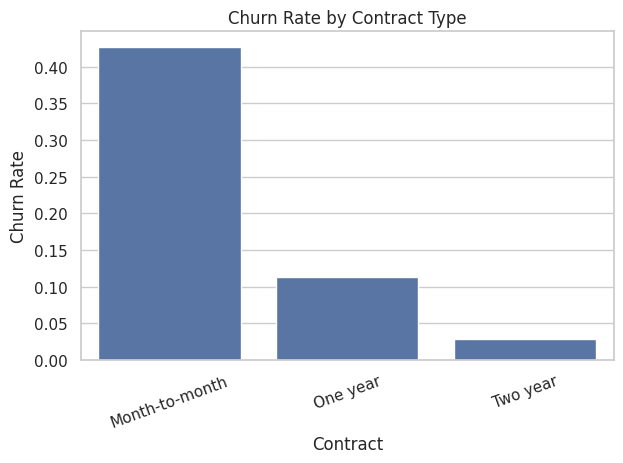

,contract,customers,churn_rate,churn_rate_pct
0,Month-to-month,3875,0.427,42.710
1,One year,1473,0.113,11.270
2,Two year,1695,0.028,2.830


In [52]:
contract_table = plot_churn_rate_by_category(
    df_raw,
    "contract",
    "Churn Rate by Contract Type",
    "eda_02_churn_by_contract.png"
)

contract_table

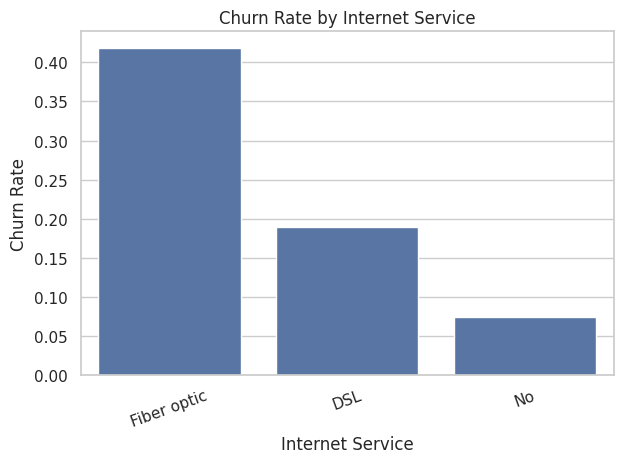

,internet_service,customers,churn_rate,churn_rate_pct
0,Fiber optic,3096,0.419,41.890
1,DSL,2421,0.190,18.960
2,No,1526,0.074,7.400


In [53]:
internet_table = plot_churn_rate_by_category(
    df_raw,
    "internet_service",
    "Churn Rate by Internet Service",
    "eda_03_churn_by_internet_service.png"
)

internet_table

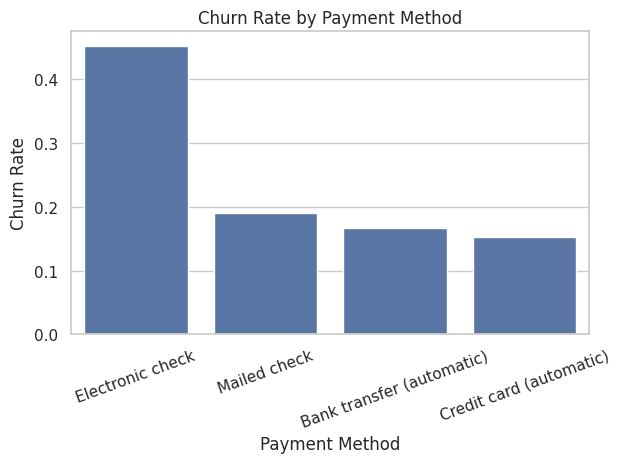

,payment_method,customers,churn_rate,churn_rate_pct
0,Electronic check,2365,0.453,45.290
1,Mailed check,1612,0.191,19.110
2,Bank transfer (automatic),1544,0.167,16.710
3,Credit card (automatic),1522,0.152,15.240


In [54]:
payment_table = plot_churn_rate_by_category(
    df_raw,
    "payment_method",
    "Churn Rate by Payment Method",
    "eda_04_churn_by_payment_method.png"
)

payment_table

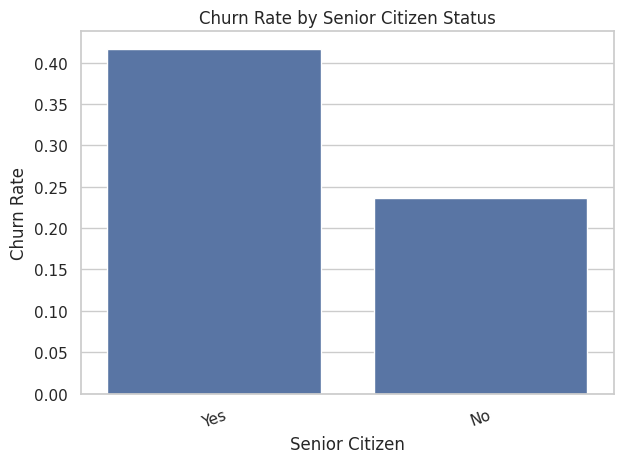

,senior_citizen,customers,churn_rate,churn_rate_pct
0,Yes,1142,0.417,41.680
1,No,5901,0.236,23.610


: 

In [ ]:
df_senior_plot = df_raw.copy()
df_senior_plot["senior_citizen"] = df_senior_plot["senior_citizen"].map({0: "No", 1: "Yes"})

senior_table = plot_churn_rate_by_category(
    df_senior_plot,
    "senior_citizen",
    "Churn Rate by Senior Citizen Status",
    "eda_05_churn_by_senior_citizen.png"
)

senior_table

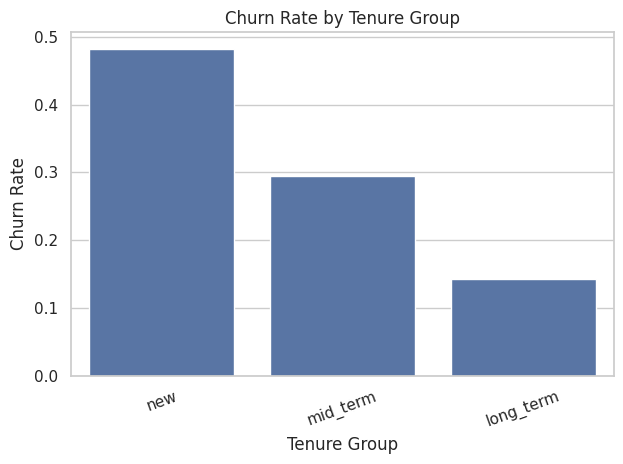

,tenure_group,customers,churn_rate,churn_rate_pct
0,new,2069,0.483,48.280
1,mid_term,1047,0.295,29.510
2,long_term,3927,0.143,14.290


In [56]:
tenure_group_table = plot_churn_rate_by_category(
    df_feat,
    "tenure_group",
    "Churn Rate by Tenure Group",
    "eda_06_churn_by_tenure_group.png"
)

tenure_group_table

## 6. Numerical variables vs churn

We compare key numerical variables between churned and retained customers:
- tenure,
- monthly charges.

These variables often provide strong signals for downstream modeling.

/tmp/ipykernel_23922/3952422697.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No churn", "Churn"])


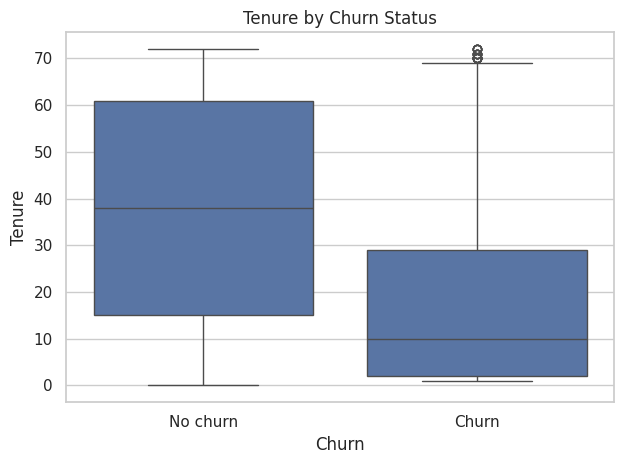

In [57]:
plot_box_by_target(
    df_raw,
    "tenure",
    "Tenure by Churn Status",
    "eda_07_tenure_by_churn.png"
)

/tmp/ipykernel_23922/3952422697.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No churn", "Churn"])


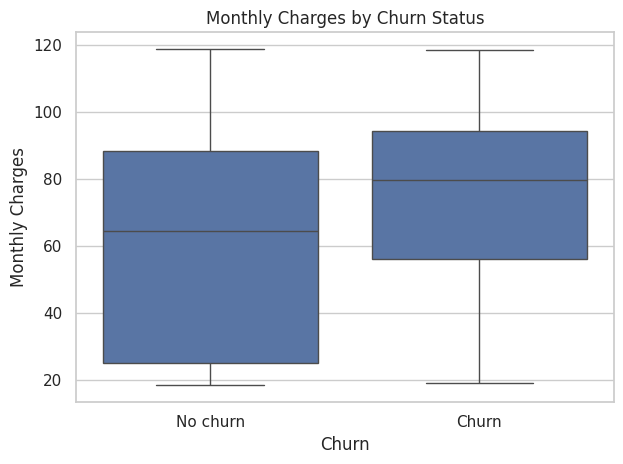

In [58]:
plot_box_by_target(
    df_raw,
    "monthly_charges",
    "Monthly Charges by Churn Status",
    "eda_08_monthly_charges_by_churn.png"
)

## 7. Additional segment summaries

Beyond the main plots, we inspect a few useful tables to identify segments with particularly high churn risk.

In [59]:
top_risk_segments = {
    "contract": churn_rate_table(df_raw, "contract"),
    "internet_service": churn_rate_table(df_raw, "internet_service"),
    "payment_method": churn_rate_table(df_raw, "payment_method"),
    "tenure_group": churn_rate_table(df_feat, "tenure_group"),
    "paperless_billing": churn_rate_table(df_raw, "paperless_billing"),
}

for name, table in top_risk_segments.items():
    print(f"\n=== {name.upper()} ===")
    display(table)


=== CONTRACT ===


,contract,customers,churn_rate,churn_rate_pct
0,Month-to-month,3875,0.427,42.710
1,One year,1473,0.113,11.270
2,Two year,1695,0.028,2.830



=== INTERNET_SERVICE ===


,internet_service,customers,churn_rate,churn_rate_pct
0,Fiber optic,3096,0.419,41.890
1,DSL,2421,0.190,18.960
2,No,1526,0.074,7.400



=== PAYMENT_METHOD ===


,payment_method,customers,churn_rate,churn_rate_pct
0,Electronic check,2365,0.453,45.290
1,Mailed check,1612,0.191,19.110
2,Bank transfer (automatic),1544,0.167,16.710
3,Credit card (automatic),1522,0.152,15.240



=== TENURE_GROUP ===


,tenure_group,customers,churn_rate,churn_rate_pct
0,new,2069,0.483,48.280
1,mid_term,1047,0.295,29.510
2,long_term,3927,0.143,14.290



=== PAPERLESS_BILLING ===


,paperless_billing,customers,churn_rate,churn_rate_pct
0,Yes,4171,0.336,33.570
1,No,2872,0.163,16.330


In [60]:
services_table = (
    df_feat.groupby("subscribed_services_count")
    .agg(
        customers=("churn", "size"),
        churn_rate=("churn", "mean")
    )
    .reset_index()
    .sort_values("subscribed_services_count")
)

services_table["churn_rate_pct"] = (services_table["churn_rate"] * 100).round(2)
services_table

,subscribed_services_count,customers,churn_rate,churn_rate_pct
0,0,2219,0.214,21.410
1,1,966,0.458,45.760
2,2,1033,0.358,35.820
3,3,1118,0.274,27.370
4,4,852,0.223,22.300
5,5,571,0.124,12.430
6,6,284,0.053,5.280


In [61]:
numeric_summary_by_churn = (
    df_raw.groupby("churn")[["tenure", "monthly_charges", "total_charges"]]
    .agg(["mean", "median"])
    .round(2)
)

numeric_summary_by_churn.index = ["No churn", "Churn"]
numeric_summary_by_churn

tenure        monthly_charges        total_charges          
           mean median            mean median          mean    median
No churn 37.570 38.000          61.270 64.430     2,555.340 1,683.600
Churn    17.980 10.000          74.440 79.650     1,531.800   703.550

## 8. Key Findings

### Main observations
1. The dataset shows a moderate class imbalance, with 73.46% non-churn customers and 26.54% churn customers.
2. Contract type is strongly associated with churn. Customers on month-to-month contracts have a much higher churn rate (42.71%) than customers on one-year (11.27%) or two-year contracts (2.83%).
3. Customer tenure is a major factor. New customers have the highest churn rate (48.28%), compared with 29.51% for mid-term customers and 14.29% for long-term customers.
4. Customers with fiber optic internet have a substantially higher churn rate (41.89%) than DSL users (18.96%) or customers with no internet service (7.40%).
5. Payment method also seems informative: customers using electronic check show the highest churn rate (45.29%), far above other payment methods.
6. Senior citizens appear more exposed to churn, with a churn rate of 41.68% versus 23.61% for non-senior customers.
7. Churned customers tend to have much lower tenure and higher monthly charges than retained customers.
8. Missing values are very limited: only 11 records have missing `total_charges`, all corresponding to customers with zero tenure, which is consistent with newly joined customers.

### Business interpretation
The results suggest that churn is not random. It is strongly linked to contract structure, customer lifecycle stage, service configuration, and billing characteristics. In particular, short-term contractual commitment and early customer lifecycle seem to be major drivers of churn risk.

### Initial hypotheses for modeling
- `contract` will likely be one of the strongest predictive variables.
- `tenure` should provide major predictive power.
- `monthly_charges` may capture price sensitivity or dissatisfaction.
- Engineered variables such as `tenure_group`, `long_contract`, and billing-related indicators should improve interpretability.

## 9. Conclusion

This exploratory analysis confirms that the dataset is suitable for churn prediction. The target is moderately imbalanced, data quality issues are limited, and several variables show strong and business-relevant relationships with churn. The most at-risk profiles are new customers, customers on month-to-month contracts, customers using fiber optic internet, and customers paying by electronic check. These findings provide a strong basis for the next step: preprocessing and feature engineering for predictive modeling.